# Práctica 2 - Ejercicio 2

Asignatura: Programación para la Inteligencia Artificial

Alumno: Francisco Javier Pérez Cazorla

Este es el segundo ejercicio de la Práctica 2 de Programación para la Inteligencia Artificial.

CIFAR100 es un conjunto de datos con dos niveles de etiquetado. Un etiquetado *fino* con 100 clases y un etiquetado *grueso* con 20 superclases. Se diseñará un sistema basado en neuronas lineales que tenga capacidad para realizar el etiquetado *fino*, pero se estudiará si la información que da el etiquetado *grueso* puede ayudar en la tarea aprovechando la probabilidad condicionada:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

$$P(A \cap B) = P(B|A)P(A)$$

El conjunto de datos está incluido en torchvision:

https.docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR100.html

Dado el tamaño del conjunto de datos y los tiempos que puede tardar el entrenamiento, se requiere que el código permita elegir dispositivo de ejecución ('cpu' o 'cuda'). En el caso de elegir la opción de ejecución en GPU (y de haber una GPU disponible), el código deberá realizar el entrenamiento en GPU de manera eficiente.

Se hará uso de las herramientas pertinentes tanto para completar el código como para realizar experimentos de los que se puedan extraer conclusiones sobre la capacidad del modelo entrenado. En el cuaderno se incluirá los experimentos más relevantes.

Como conjunto de test se usará el conjunto de test íntegro que provee el conjunto de datos.

# 1. Configuración y Bibliotecas

In [1]:
# === Celda 1: Importación de Bibliotecas ===
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset
import os
import time
import pickle  # Para cargar etiquetas gruesas
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
# === Celda 2: Configuración del Dispositivo ===
if torch.cuda.is_available():
    dispositivo_calculo = torch.device("cuda")
else:
    dispositivo_calculo = torch.device("cpu")

print(f"[INFO] Dispositivo de cómputo seleccionado: {dispositivo_calculo}")

[INFO] Dispositivo de cómputo seleccionado: cuda


In [3]:
# === Celda 3: Rutas y Transformaciones ===
ruta_datos = '/content/cifar100_data_vC'

# Transformación única para convertir imágenes PIL a Tensores [0, 1]
transformacion_tensor = transforms.Compose([
    transforms.ToTensor()
])

# 2. Clases y Funciones de Utilidad

Agrupamos todas las clases y funciones de ayuda en una sola celda para organizar el código.

In [4]:
# === Celda 4: Funciones y Clases de Ayuda ===

def decodificar_pickle(archivo):
    """Función auxiliar para abrir archivos pickle de CIFAR."""
    with open(archivo, 'rb') as f:
        diccionario = pickle.load(f, encoding='bytes')
    return diccionario

def cargar_etiquetas_gruesas(ruta_raiz, es_entrenamiento=True):
    """
    Carga manualmente las etiquetas 'coarse' (gruesas) desde los archivos
    del dataset CIFAR-100, ya que torchvision no lo facilita.
    """
    if es_entrenamiento:
        archivo = os.path.join(ruta_raiz, 'cifar-100-python', 'train')
        datos = decodificar_pickle(archivo)
        return datos[b'coarse_labels']
    else:
        archivo = os.path.join(ruta_raiz, 'cifar-100-python', 'test')
        datos = decodificar_pickle(archivo)
        return datos[b'coarse_labels']

def crear_indices_division(total_items, ratio_ent=0.9):
    """
    Genera índices aleatorios para la división entrenamiento/validación.
    Usa torch.randperm para ser más eficiente.
    """
    indices_permutados = torch.randperm(total_items)
    limite = int(total_items * ratio_ent)
    idx_ent = indices_permutados[:limite]
    idx_val = indices_permutados[limite:]
    return idx_ent, idx_val

class DatasetEnVRAM(Dataset):
    """
    Dataset que precarga todas las imágenes y etiquetas en la memoria
    del dispositivo (VRAM) para un entrenamiento ultra-rápido.
    """
    def __init__(self, dataset_base, dispositivo):
        self.dispositivo = dispositivo
        imagenes, etiquetas = [], []

        print(f"... Precargando {len(dataset_base)} elementos en {dispositivo}...")
        for i in tqdm(range(len(dataset_base))):
            img, etq = dataset_base[i]
            imagenes.append(img)
            etiquetas.append(etq)

        self.imagenes_gpu = torch.stack(imagenes).to(dispositivo, non_blocking=True)
        self.etiquetas_gpu = torch.tensor(etiquetas, device=dispositivo, dtype=torch.long)
        print(f"+++ Precarga en {dispositivo} completada. +++")

    def __len__(self):
        return len(self.imagenes_gpu)

    def __getitem__(self, idx):
        return self.imagenes_gpu[idx], self.etiquetas_gpu[idx]

class MonitorPaciencia():
  """
  Utilidad para detener el entrenamiento si la pérdida de validación
  no mejora después de 'max_paciencia' épocas.
  """
  def __init__(self, max_paciencia=10, diferencia_minima=0.01):
    self.max_paciencia = max_paciencia
    self.diferencia_minima = diferencia_minima
    self.mejor_perdida = None
    self.contador_paciencia = 0
    self.detener_entrenamiento = False

  def evaluar(self, perdida_actual):
    if self.mejor_perdida is None:
      self.mejor_perdida = perdida_actual
    elif (perdida_actual + self.diferencia_minima) < self.mejor_perdida:
      self.mejor_perdida = perdida_actual
      self.contador_paciencia = 0
    else:
      self.contador_paciencia += 1
      if self.contador_paciencia >= self.max_paciencia:
        print(f"\n[ALERTA] Early Stopping: No hay mejora en {self.max_paciencia} épocas.")
        self.detener_entrenamiento = True


# 3. Carga Principal de Datos

Esta celda utiliza las funciones de utilidad de arriba para cargar y procesar todos los datasets de CIFAR-100.

In [6]:
# === Celda 5: Carga y Procesamiento de Datos ===

TAMAÑO_LOTE = 512

# --- 1. Cargar Datasets Base (en CPU) ---
print("[INFO] Cargando datasets base en CPU...")
datos_fino_cpu = datasets.CIFAR100(
    root=ruta_datos, train=True, download=True, transform=transformacion_tensor
)
datos_grueso_cpu = datasets.CIFAR100(
    root=ruta_datos, train=True, download=True, transform=transformacion_tensor
)

# Sobrescribir las etiquetas del dataset grueso con las correctas
etiquetas_gruesas_ent = cargar_etiquetas_gruesas(ruta_datos, es_entrenamiento=True)
datos_grueso_cpu.targets = etiquetas_gruesas_ent
print(f"... {len(datos_grueso_cpu.targets)} etiquetas de entrenamiento gruesas reemplazadas.")

# --- 2. Cargar Datasets de Test (en CPU) ---
test_fino_cpu = datasets.CIFAR100(
    root=ruta_datos, train=False, download=True, transform=transformacion_tensor
)
test_grueso_cpu = datasets.CIFAR100(
    root=ruta_datos, train=False, download=True, transform=transformacion_tensor
)
etiquetas_gruesas_test = cargar_etiquetas_gruesas(ruta_datos, es_entrenamiento=False)
test_grueso_cpu.targets = etiquetas_gruesas_test
print(f"... {len(test_grueso_cpu.targets)} etiquetas de prueba gruesas reemplazadas.")

# --- 3. Crear División Entrenamiento/Validación (90/10) ---
print("\n[INFO] Creando división Train/Val...")
indices_ent, indices_val = crear_indices_division(len(datos_fino_cpu), ratio_ent=0.9)
print(f"\n       Total: {len(datos_fino_cpu)}")
print(f"\n       Train: {len(indices_ent)}")
print(f"\n       Val: {len(indices_val)}")

# --- 4. Crear Subsets de CPU ---
ent_fino_cpu = Subset(datos_fino_cpu, indices_ent)
val_fino_cpu = Subset(datos_fino_cpu, indices_val)
ent_grueso_cpu = Subset(datos_grueso_cpu, indices_ent)
val_grueso_cpu = Subset(datos_grueso_cpu, indices_val)

# --- 5. Precargar todos los datasets en el dispositivo (GPU) ---
print(f"\n[INFO] Transfiriendo datasets a {dispositivo_calculo}...")
ent_fino_gpu = DatasetEnVRAM(ent_fino_cpu, dispositivo_calculo)
val_fino_gpu = DatasetEnVRAM(val_fino_cpu, dispositivo_calculo)
test_fino_gpu = DatasetEnVRAM(test_fino_cpu, dispositivo_calculo)

ent_grueso_gpu = DatasetEnVRAM(ent_grueso_cpu, dispositivo_calculo)
val_grueso_gpu = DatasetEnVRAM(val_grueso_cpu, dispositivo_calculo)
test_grueso_gpu = DatasetEnVRAM(test_grueso_cpu, dispositivo_calculo)

# --- 6. Crear los DataLoaders finales ---
print("\n[INFO] Creando DataLoaders...")
cargador_fino_ent = DataLoader(ent_fino_gpu, batch_size=TAMAÑO_LOTE, shuffle=True)
cargador_fino_val = DataLoader(val_fino_gpu, batch_size=TAMAÑO_LOTE, shuffle=False)
cargador_fino_test = DataLoader(test_fino_gpu, batch_size=TAMAÑO_LOTE, shuffle=False)

cargador_grueso_ent = DataLoader(ent_grueso_gpu, batch_size=TAMAÑO_LOTE, shuffle=True)
cargador_grueso_val = DataLoader(val_grueso_gpu, batch_size=TAMAÑO_LOTE, shuffle=False)
cargador_grueso_test = DataLoader(test_grueso_gpu, batch_size=TAMAÑO_LOTE, shuffle=False)

print("\n*** Proceso de carga de datos completado. ***")

[INFO] Cargando datasets base en CPU...
... 50000 etiquetas de entrenamiento gruesas reemplazadas.
... 10000 etiquetas de prueba gruesas reemplazadas.

[INFO] Creando división Train/Val...

       Total: 50000

       Train: 45000

       Val: 5000

[INFO] Transfiriendo datasets a cuda...
... Precargando 45000 elementos en cuda...


100%|██████████| 45000/45000 [00:07<00:00, 6111.93it/s]


+++ Precarga en cuda completada. +++
... Precargando 5000 elementos en cuda...


100%|██████████| 5000/5000 [00:00<00:00, 7497.25it/s]


+++ Precarga en cuda completada. +++
... Precargando 10000 elementos en cuda...


...

+++ Precarga en cuda completada. +++
... Precargando 5000 elementos en cuda...


100%|██████████| 5000/5000 [00:00<00:00, 5870.61it/s]


+++ Precarga en cuda completada. +++
... Precargando 10000 elementos en cuda...


100%|██████████| 10000/10000 [00:01<00:00, 6020.59it/s]


+++ Precarga en cuda completada. +++

[INFO] Creando DataLoaders...

*** Proceso de carga de datos completado. ***


# 4. Clase de Modelo y Entrenador

Creamos una clase `RedLineal` que define el modelo y una clase `Entrenador` que maneja todo el proceso de entrenamiento y evaluación.

In [7]:
# === Celda 6: Clase del Modelo y del Entrenador ===

class RedLineal(nn.Module):
    """Define la arquitectura del modelo lineal simple."""
    def __init__(self, dim_entrada, dim_salida, dim_oculta=128):
        super().__init__()
        self.capas = nn.Sequential(
            nn.Flatten(),
            nn.Linear(dim_entrada, dim_oculta),
            nn.Linear(dim_oculta, dim_salida)
        )

    def forward(self, x):
        return self.capas(x)

class Entrenador:
    """
    Clase que encapsula el modelo, los datos y la lógica de
    entrenamiento y evaluación.
    """
    def __init__(self, modelo, cargador_ent, cargador_val, cargador_test):
        self.modelo = modelo
        self.cargador_ent = cargador_ent
        self.cargador_val = cargador_val
        self.cargador_test = cargador_test
        self.historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    def bucle_entrenamiento(self, criterio, optimizador_clase, lr, max_epocas, monitor):
        """Método que contiene el bucle de entrenamiento."""
        optimizador = optimizador_clase(self.modelo.parameters(), lr=lr)
        dispositivo = next(self.modelo.parameters()).device

        barra_epocas = tqdm(range(max_epocas), desc="Entrenando")
        for epoca in barra_epocas:
            perdidas_lote_ent = []

            for imagenes, etiquetas in self.cargador_ent:
                predicciones = self.modelo(imagenes)
                optimizador.zero_grad()
                perdida = criterio(predicciones, etiquetas)
                perdida.backward()
                optimizador.step()
                perdidas_lote_ent.append(perdida.clone().detach())

            perdida_epoca_ent = torch.tensor(perdidas_lote_ent).mean().item()
            self.historial['train_loss'].append(perdida_epoca_ent)
            barra_epocas.set_postfix(loss=f"{perdida_epoca_ent:.4f}")

            # --- Validación ---
            perdidas_lote_val, total_correctas, total_muestras = [], 0, 0
            with torch.no_grad():
                for imagenes_val, etiquetas_val in self.cargador_val:
                    pred_val = self.modelo(imagenes_val)
                    perdidas_lote_val.append(criterio(pred_val, etiquetas_val).clone().detach())
                    total_correctas += torch.sum(etiquetas_val == torch.argmax(pred_val, dim=-1))
                    total_muestras += etiquetas_val.numel()

            perdida_epoca_val = torch.tensor(perdidas_lote_val).mean().item()
            acc_epoca_val = (total_correctas / float(total_muestras)).item()
            self.historial['val_loss'].append(perdida_epoca_val)
            self.historial['val_acc'].append(acc_epoca_val)

            monitor.evaluar(perdida_epoca_val)
            if monitor.detener_entrenamiento:
                break

        return self.historial

    def ejecutar_evaluacion(self, return_logits=False):
        """Método para evaluar el modelo en el conjunto de test."""
        lista_logits, lista_preds, lista_reales = [], [], []

        with torch.no_grad():
            for imagenes, etiquetas in tqdm(self.cargador_test, desc="Evaluando"):
                logits = self.modelo(imagenes)
                preds = torch.argmax(logits, dim=-1)
                lista_logits.append(logits.cpu())
                lista_preds.append(preds.cpu())
                lista_reales.append(etiquetas.cpu())

        if return_logits:
            return torch.cat(lista_logits), torch.cat(lista_reales)
        else:
            return torch.cat(lista_preds), torch.cat(lista_reales)


# 5. Entrenamiento de Modelos

Ahora instanciamos nuestros modelos `RedLineal` y nuestros `Entrenador`es.

In [8]:
# === Celda 7: Entrenamiento ===

# --- Hiperparámetros de Entrenamiento ---
DIM_ENTRADA = 3 * 32 * 32
DIM_OCULTA = 128
TASA_APREN = 2e-4
MAX_EPOCAS = 500
CRITERIO = nn.CrossEntropyLoss()
OPTIMIZADOR = torch.optim.Adam
PACIENCIA = 15
DELTA_MEJORA = 0.005

# --- 1. Entrenamiento del Modelo FINO (100 clases) ---
print("\n===== INICIO ENTRENAMIENTO: MODELO FINO (100) =====")
modelo_fino = RedLineal(DIM_ENTRADA, 100, DIM_OCULTA).to(dispositivo_calculo)
monitor_fino = MonitorPaciencia(max_paciencia=PACIENCIA, diferencia_minima=DELTA_MEJORA)
entrenador_fino = Entrenador(modelo_fino, cargador_fino_ent, cargador_fino_val, cargador_fino_test)

historial_fino = entrenador_fino.bucle_entrenamiento(
    CRITERIO, OPTIMIZADOR, TASA_APREN, MAX_EPOCAS, monitor_fino
)

# --- 2. Entrenamiento del Modelo GRUESO (20 clases) ---
print("\n===== INICIO ENTRENAMIENTO: MODELO GRUESO (20) =====")
modelo_grueso = RedLineal(DIM_ENTRADA, 20, DIM_OCULTA).to(dispositivo_calculo)
monitor_grueso = MonitorPaciencia(max_paciencia=PACIENCIA, diferencia_minima=DELTA_MEJORA)
entrenador_grueso = Entrenador(modelo_grueso, cargador_grueso_ent, cargador_grueso_val, cargador_grueso_test)

historial_grueso = entrenador_grueso.bucle_entrenamiento(
    CRITERIO, OPTIMIZADOR, TASA_APREN, MAX_EPOCAS, monitor_grueso
)

print("\n===== ENTRENAMIENTOS FINALIZADOS =====")


===== INICIO ENTRENAMIENTO: MODELO FINO (100) =====


Entrenando:  12%|█▏        | 61/500 [00:34<04:10,  1.75it/s, loss=3.3414]



[ALERTA] Early Stopping: No hay mejora en 15 épocas.

===== INICIO ENTRENAMIENTO: MODELO GRUESO (20) =====


Entrenando:   9%|▉         | 46/500 [00:25<04:13,  1.79it/s, loss=2.3447]


[ALERTA] Early Stopping: No hay mejora en 15 épocas.

===== ENTRENAMIENTOS FINALIZADOS =====


# 6. Evaluación - Enfoque 1 (Directo - 100 Clases)

--- Visualización: Curvas de Aprendizaje (Modelo Fino) ---


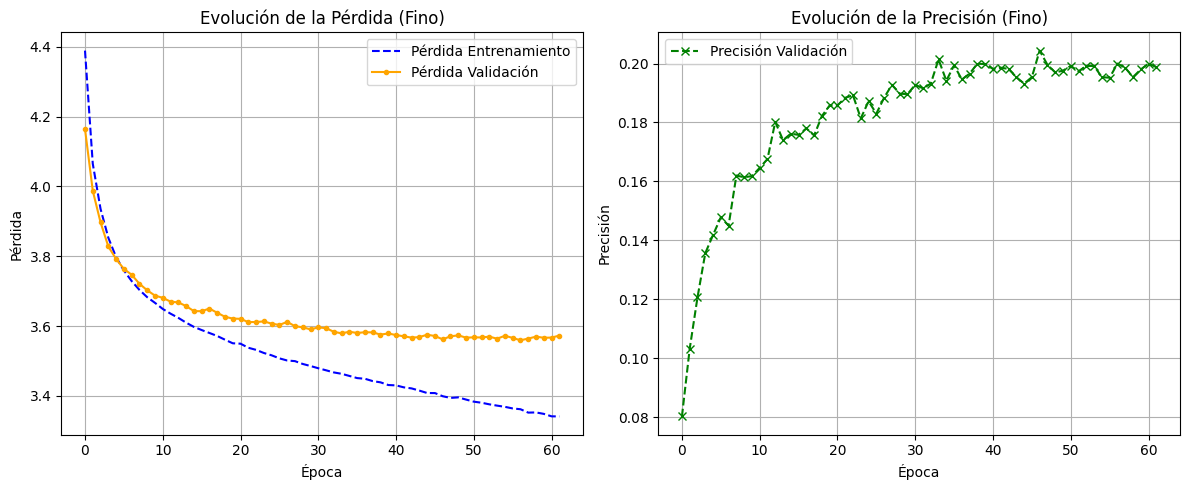

In [9]:
# === Celda 8: Gráficas (Enfoque 1) ===
print("--- Visualización: Curvas de Aprendizaje (Modelo Fino) ---")
plt.figure(figsize=(12, 5))

# Gráfico de Pérdida
plt.subplot(1, 2, 1)
plt.plot(historial_fino['train_loss'], label="Pérdida Entrenamiento", color="blue", linestyle="--")
plt.plot(historial_fino['val_loss'], label="Pérdida Validación", color="orange", marker="o", markersize=3)
plt.title("Evolución de la Pérdida (Fino)")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)

# Gráfico de Precisión
plt.subplot(1, 2, 2)
plt.plot(historial_fino['val_acc'], label="Precisión Validación", color="green", marker="x", linestyle="--")
plt.title("Evolución de la Precisión (Fino)")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

>>> Iniciando Evaluación de Test [Enfoque 1: Directo-Fino]...



Evaluando: 100%|██████████| 20/20 [00:00<00:00, 212.91it/s]


*** Precisión Global [ENFOQUE 1]: 18.56% ***

... Preparando visualización de Matriz (100x100)...



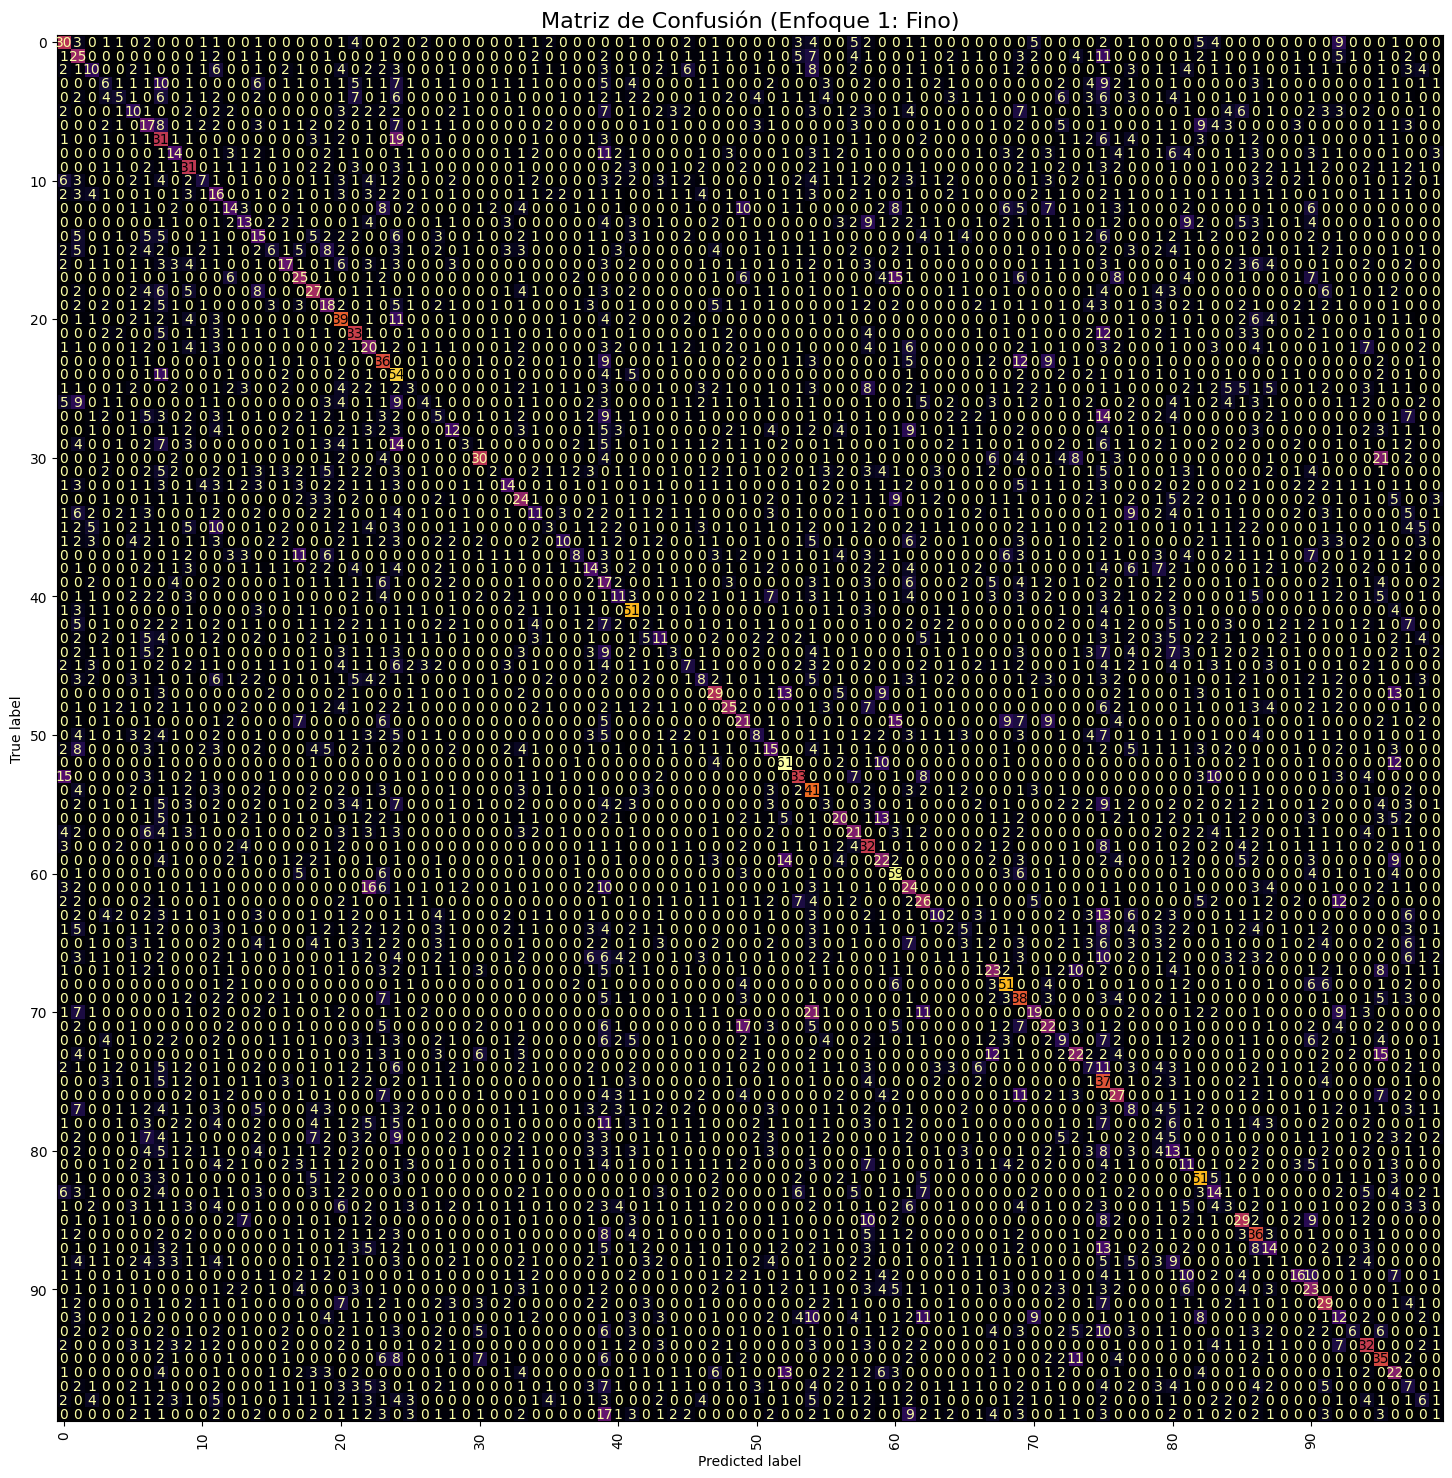

In [10]:
# === Celda 9: Matriz de Confusión (Enfoque 1) ===

print(">>> Iniciando Evaluación de Test [Enfoque 1: Directo-Fino]...\n")
predicciones_e1, reales_e1 = entrenador_fino.ejecutar_evaluacion(return_logits=False)

accuracy_e1 = accuracy_score(reales_e1, predicciones_e1)
print(f"\n*** Precisión Global [ENFOQUE 1]: {accuracy_e1 * 100:.2f}% ***\n")

print("... Preparando visualización de Matriz (100x100)...\n")
cm_e1 = confusion_matrix(reales_e1, predicciones_e1)

fig, ax = plt.subplots(figsize=(18, 18))
etiquetas_clases_fino = [str(i) for i in range(100)]
display_matrix_e1 = ConfusionMatrixDisplay(cm_e1, display_labels=etiquetas_clases_fino)

display_matrix_e1.plot(cmap='inferno', ax=ax, xticks_rotation='vertical', colorbar=False)

ticks_principales_fino = np.arange(0, 100, 10)
ax.set_xticks(ticks_principales_fino)
ax.set_yticks(ticks_principales_fino)
ax.set_xticklabels(ticks_principales_fino, rotation='vertical')
ax.set_yticklabels(ticks_principales_fino)

ax.set_title("Matriz de Confusión (Enfoque 1: Fino)", fontsize=16)
ax.grid(False)
plt.show()

# 7. Evaluación - Enfoque 2 (Base - 20 Superclases)

--- Visualización: Curvas de Aprendizaje (Modelo Grueso) ---


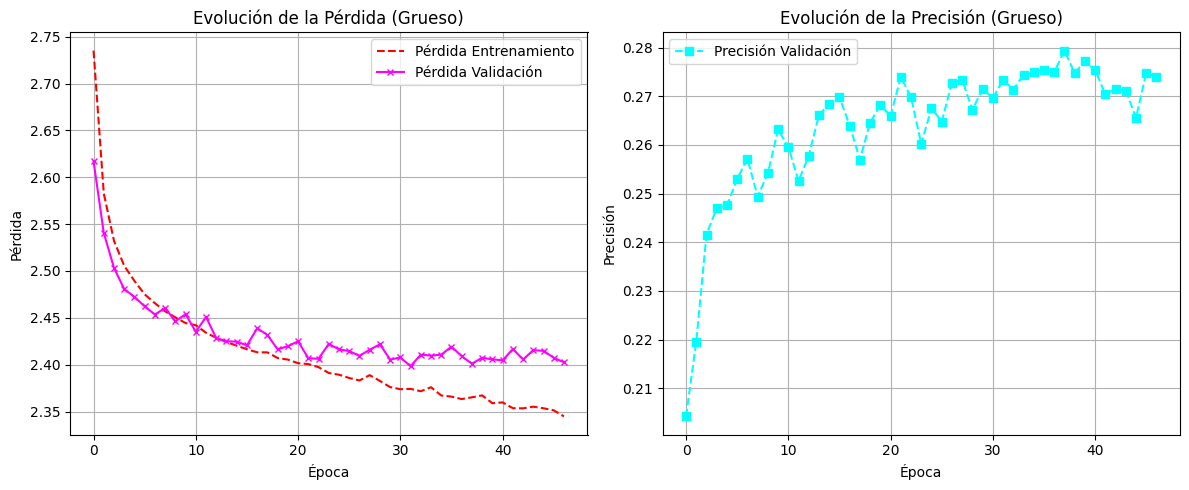

In [11]:
# === Celda 10: Gráficas (Enfoque 2) ===
print("--- Visualización: Curvas de Aprendizaje (Modelo Grueso) ---")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(historial_grueso['train_loss'], label="Pérdida Entrenamiento", color="red", linestyle="--")
plt.plot(historial_grueso['val_loss'], label="Pérdida Validación", color="magenta", marker="x", markersize=5)
plt.title("Evolución de la Pérdida (Grueso)")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(historial_grueso['val_acc'], label="Precisión Validación", color="cyan", marker="s", linestyle="--")
plt.title("Evolución de la Precisión (Grueso)")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

>>> Iniciando Evaluación de Test [Enfoque 2: Base-Grueso]...



Evaluando: 100%|██████████| 20/20 [00:00<00:00, 190.50it/s]


*** Precisión Global [ENFOQUE 2]: 25.82% ***

... Preparando visualización de Matriz (20x20)...



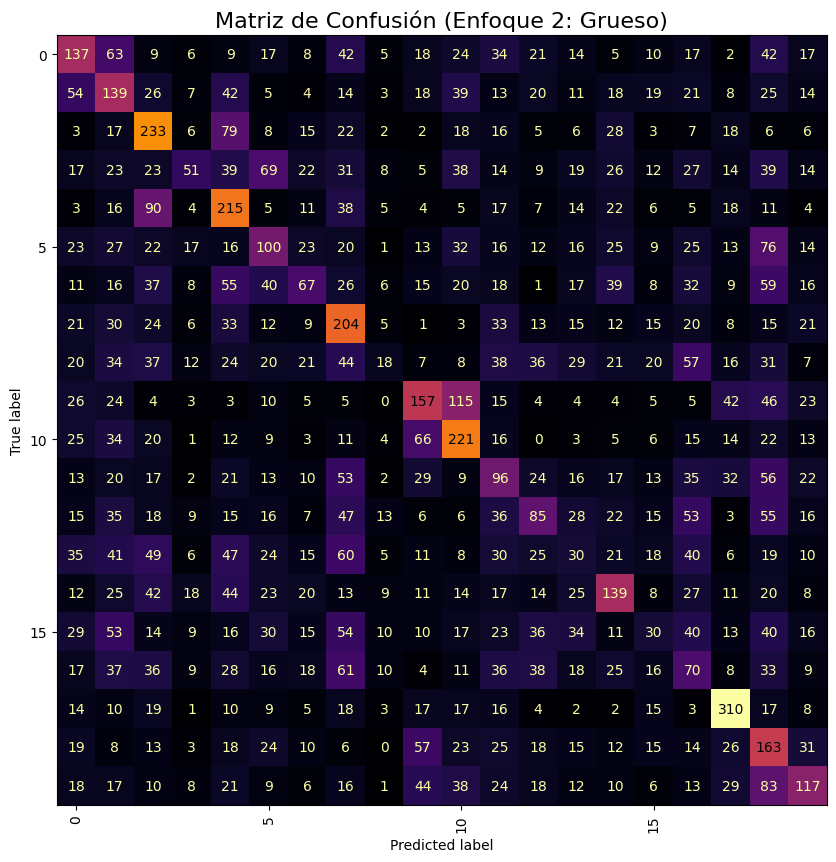

In [12]:
# === Celda 11: Matriz de Confusión (Enfoque 2) ===

print(">>> Iniciando Evaluación de Test [Enfoque 2: Base-Grueso]...\n")
predicciones_e2, reales_e2 = entrenador_grueso.ejecutar_evaluacion(return_logits=False)

accuracy_e2 = accuracy_score(reales_e2, predicciones_e2)
print(f"\n*** Precisión Global [ENFOQUE 2]: {accuracy_e2 * 100:.2f}% ***\n")

print("... Preparando visualización de Matriz (20x20)...\n")
cm_e2 = confusion_matrix(reales_e2, predicciones_e2)

fig, ax = plt.subplots(figsize=(10, 10))
etiquetas_clases_grueso = [str(i) for i in range(20)]
display_matrix_e2 = ConfusionMatrixDisplay(cm_e2, display_labels=etiquetas_clases_grueso)

display_matrix_e2.plot(cmap='inferno', ax=ax, xticks_rotation='vertical', colorbar=False)

ticks_principales_grueso = np.arange(0, 20, 5)
ax.set_xticks(ticks_principales_grueso)
ax.set_yticks(ticks_principales_grueso)
ax.set_xticklabels(ticks_principales_grueso, rotation='vertical')
ax.set_yticklabels(ticks_principales_grueso)

ax.set_title("Matriz de Confusión (Enfoque 2: Grueso)", fontsize=16)
ax.grid(False)
plt.show()

# 8. Evaluación - Enfoque 3 (Jerárquico)

Implementamos la lógica jerárquica combinando las salidas de ambos modelos.

$P(\text{fina}) = P(\text{fina} | \text{modelo\_fino}) \times P(\text{gruesa} | \text{modelo\_grueso})$

In [13]:
# === Celda 12: Lógica de Combinación Jerárquica ===

print(">>> Iniciando Evaluación de Test [Enfoque 3: Jerárquico]...\n")

# 1. Obtener logits (salidas crudas) de ambos modelos
logits_fino, reales_fino_e3 = entrenador_fino.ejecutar_evaluacion(return_logits=True)
logits_grueso, _ = entrenador_grueso.ejecutar_evaluacion(return_logits=True)

# 2. Convertir logits a probabilidades usando Softmax (en la CPU)
probs_fino = torch.softmax(logits_fino, dim=-1)
probs_grueso = torch.softmax(logits_grueso, dim=-1)

# 3. Mapa de Superclases (Gruesas) a Clases (Finas)
mapa_grueso_a_fino_lista = [
    [4, 30, 55, 72, 95], [1, 32, 67, 73, 91], [54, 62, 70, 82, 92], [9, 10, 16, 28, 61],
    [0, 51, 53, 57, 83], [22, 39, 40, 86, 87], [5, 20, 26, 84, 94], [6, 7, 14, 18, 24],
    [3, 42, 43, 88, 97], [12, 17, 37, 68, 76], [25, 29, 34, 60, 63], [15, 19, 21, 31, 38],
    [33, 47, 49, 77, 79], [11, 35, 46, 66, 98], [2, 13, 48, 58, 90], [41, 65, 74, 75, 89],
    [23, 36, 50, 64, 78], [27, 45, 52, 59, 99], [8, 44, 56, 80, 93], [71, 81, 85, 96, 50]
]

matriz_mapeo = torch.zeros(20, 100)
for idx_superclase, lista_clases in enumerate(mapa_grueso_a_fino_lista):
    for idx_clase in lista_clases:
        matriz_mapeo[idx_superclase, idx_clase] = 1.0

# 4. "Difundir" las probabilidades gruesas a las 100 clases finas
# Multiplicación de matrices: [N_muestras, 20] @ [20, 100] -> [N_muestras, 100]
probs_grueso_difundidas = probs_grueso @ matriz_mapeo

# 5. Combinar probabilidades (Heurística)
probs_final_jerarquica = probs_grueso_difundidas * probs_fino

# 6. Obtener la predicción final
predicciones_e3 = torch.argmax(probs_final_jerarquica, dim=-1)

print("... Cálculo jerárquico completado.\n")

>>> Iniciando Evaluación de Test [Enfoque 3: Jerárquico]...



Evaluando: 100%|██████████| 20/20 [00:00<00:00, 181.80it/s]

... Cálculo jerárquico completado.




*** Precisión Global [ENFOQUE 3 - JERÁRQUICO]: 15.72% ***

... Preparando visualización de Matriz Jerárquica (100x100)...



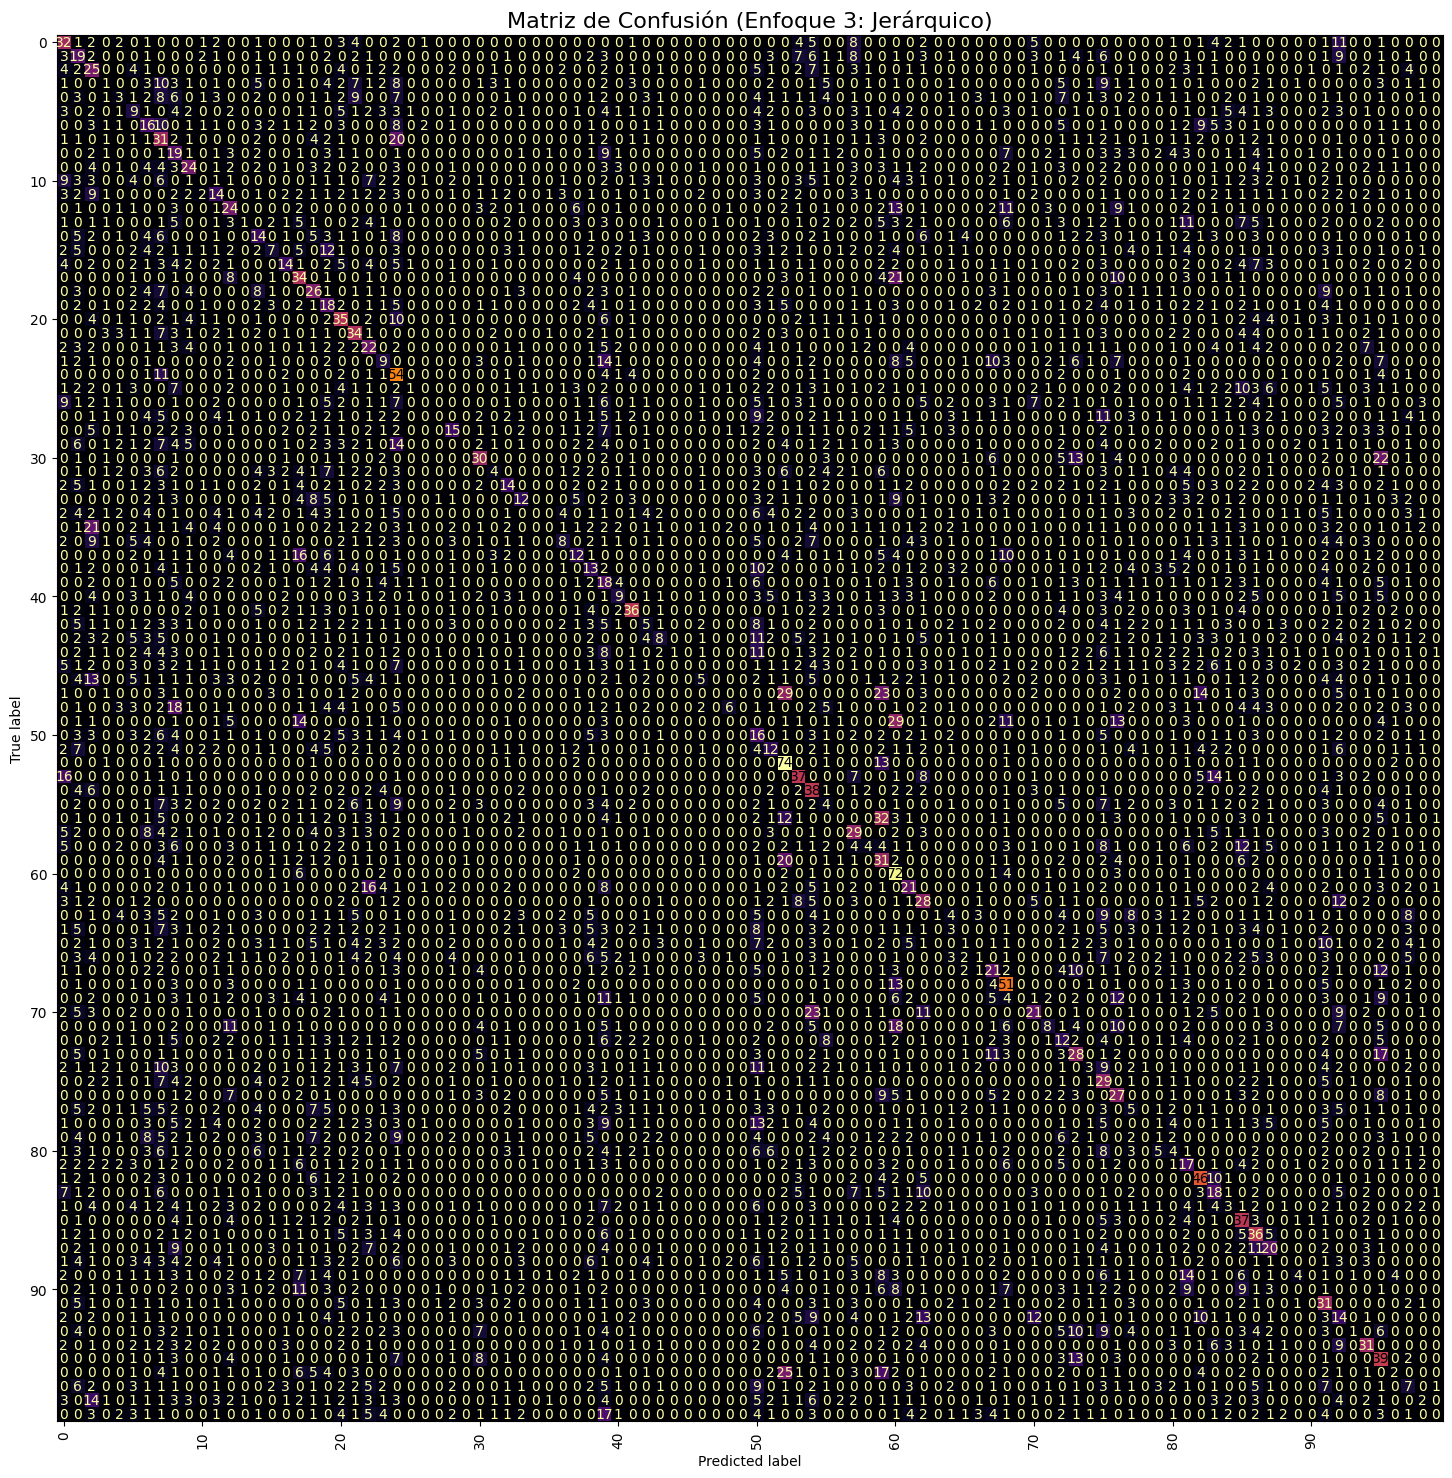

In [14]:
# === Celda 13: Matriz de Confusión (Enfoque 3) ===

# Calcular Accuracy
accuracy_e3 = accuracy_score(reales_fino_e3, predicciones_e3)
print(f"\n*** Precisión Global [ENFOQUE 3 - JERÁRQUICO]: {accuracy_e3 * 100:.2f}% ***\n")

print("... Preparando visualización de Matriz Jerárquica (100x100)...\n")
cm_e3 = confusion_matrix(reales_fino_e3, predicciones_e3)

# --- Visualización (Estilo C) ---
fig, ax = plt.subplots(figsize=(18, 18))
display_matrix_e3 = ConfusionMatrixDisplay(cm_e3, display_labels=etiquetas_clases_fino)

display_matrix_e3.plot(cmap='inferno', ax=ax, xticks_rotation='vertical', colorbar=False)

ax.set_xticks(ticks_principales_fino)
ax.set_yticks(ticks_principales_fino)
ax.set_xticklabels(ticks_principales_fino, rotation='vertical')
ax.set_yticklabels(ticks_principales_fino)

ax.set_title("Matriz de Confusión (Enfoque 3: Jerárquico)", fontsize=16)
ax.grid(False)
plt.show()